In [ ]:
from geotiff import GeoTiff
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from geopy.distance import geodesic

In [61]:
%matplotlib inline

In [67]:
tiff_file = "assets/DGM_R100.tif"
geo_tiff = GeoTiff(tiff_file)

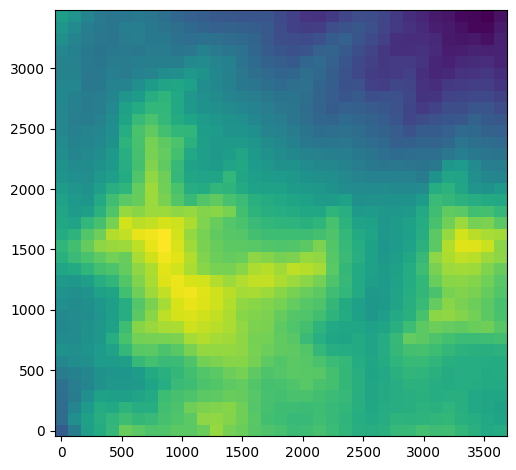

In [ ]:
def coord_arrays_to_meters(lat, lon):
    origin = (np.min(lat), np.min(lon))
    x_array = np.zeros_like(lon)
    y_array = np.zeros_like(lat)
    for i in range(lat.shape[0]):
        for j in range(lat.shape[1]):
            point = (lat[i, j], lon[i, j])
            x_array[i, j] = geodesic(origin, (origin[0], point[1])).meters
            y_array[i, j] = geodesic(origin, (point[0], origin[1])).meters
    return x_array, y_array

def generate_rectified_coord_arrays(wgs_84_box, xlen, ylen):
    origin = wgs_84_box[0]
    max = wgs_84_box[1]
    x = np.linspace(0, geodesic(origin, (origin[0], max[1])).meters, xlen)
    y = np.linspace(0, geodesic(origin, (max[0], origin[1])).meters, ylen)

    xarr, yarr= np.meshgrid(x, y, indexing="ij")
    return xarr, yarr

bbox = ((14.039583, 47.691855), (14.089708, 47.723852))
array = geo_tiff.read_box(bbox)
if array.size == 0:
    print("No data found in the specified bounding box.")
if array.size > 0:
    fig, ax = plt.subplots()
    lon_array, lat_array = geo_tiff.get_coord_arrays(bbox)
    geowgs_84_box = ((np.min(lat_array), np.min(lon_array)), (np.max(lat_array), np.max(lon_array)))
    # If using:
    # geo_tiff.get_bBox_wgs_84(bbox)
    # The returning bounding box is invalid.
    x_array, y_array = generate_rectified_coord_arrays(geowgs_84_box, lon_array.shape[0], lon_array.shape[1])
    # x_array, y_array = coord_arrays_to_meters(lat_array, lon_array)
    ax.pcolormesh(x_array, y_array, array, cmap="viridis")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

array([[0.00000000e+00, 9.07825338e-01, 1.81736706e+00, ...,
        3.18289454e+01, 3.27951272e+01, 3.37630253e+01],
       [1.00028377e+02, 1.00936187e+02, 1.01845714e+02, ...,
        1.31856779e+02, 1.32822944e+02, 1.33790826e+02],
       [2.00056761e+02, 2.00964555e+02, 2.01874066e+02, ...,
        2.31884619e+02, 2.32850768e+02, 2.33818633e+02],
       ...,
       [3.20091096e+03, 3.20181829e+03, 3.20272733e+03, ...,
        3.23272251e+03, 3.23368817e+03, 3.23465554e+03],
       [3.30093952e+03, 3.30184683e+03, 3.30275586e+03, ...,
        3.33275053e+03, 3.33371617e+03, 3.33468352e+03],
       [3.40096808e+03, 3.40187538e+03, 3.40278440e+03, ...,
        3.43277855e+03, 3.43374417e+03, 3.43471151e+03]], shape=(35, 37))

In [22]:
import numpy as np
from stl import mesh
%matplotlib inline

# Define the 8 vertices of the cube
vertices = np.array([\
    [-1, -1, -1],
    [+1, -1, -1],
    [+1, +1, -1],
    [-1, +1, -1],
    [-1, -1, +1],
    [+1, -1, +1],
    [+1, +1, +1],
    [-1, +1, +1]])
# Define the 12 triangles composing the cube
faces = np.array([\
    [0,3,1],
    [1,3,2],
    [0,4,7],
    [0,7,3],
    [4,5,6],
    [4,6,7],
    [5,1,2],
    [5,2,6],
    [2,3,6],
    [3,7,6],
    [0,1,5],
    [0,5,4]])

# Create the mesh
cube = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
#for i, f in enumerate(faces):
#    for j in range(3):
#        cube.vectors[i][j] = vertices[f[j],:]

figure = plt.figure()
axes = mplot3d.Axes3D(figure)

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(cube.vectors))

# Auto scale to the mesh size
scale = cube.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
cube.vectors

array([[[-1., -1., -1.],
        [-1.,  1., -1.],
        [ 1., -1., -1.]],

       [[ 1., -1., -1.],
        [-1.,  1., -1.],
        [ 1.,  1., -1.]],

       [[-1., -1., -1.],
        [-1., -1.,  1.],
        [-1.,  1.,  1.]],

       [[-1., -1., -1.],
        [-1.,  1.,  1.],
        [-1.,  1., -1.]],

       [[-1., -1.,  1.],
        [ 1., -1.,  1.],
        [ 1.,  1.,  1.]],

       [[-1., -1.,  1.],
        [ 1.,  1.,  1.],
        [-1.,  1.,  1.]],

       [[ 1., -1.,  1.],
        [ 1., -1., -1.],
        [ 1.,  1., -1.]],

       [[ 1., -1.,  1.],
        [ 1.,  1., -1.],
        [ 1.,  1.,  1.]],

       [[ 1.,  1., -1.],
        [-1.,  1., -1.],
        [ 1.,  1.,  1.]],

       [[-1.,  1., -1.],
        [-1.,  1.,  1.],
        [ 1.,  1.,  1.]],

       [[-1., -1., -1.],
        [ 1., -1., -1.],
        [ 1., -1.,  1.]],

       [[-1., -1., -1.],
        [ 1., -1.,  1.],
        [-1., -1.,  1.]]], dtype=float32)